## Task 1: Understand the Business Problem

1. What is the main business problem?

   The main business problem is supplier delivery uncertainty. ProcurePro Office Supplies works with multiple suppliers, but some orders arrive on time while others are delayed due to backorders, low supplier on time performance, long delivery distance, urgent order pressure, seasonal demand spikes, or past supplier quality issues. 

2. Why is customer/user segmentation useful for this business?

   Customer segmentation is useful because it helps ProcurePro discover groups of similar purchase orders or suppliers. Instead of treating every order the same, the company can group orders based on patterns such as order value, number of items, promised lead time, distance, supplier rating, past on time rate, prior delays, seasonal demand, and inventory buffer. This helps the business understand which groups are more reliable, which groups are more risky, and which groups may need more attention.

3. What kind of marketing decisions could be improved by discovering customer/user groups?

   Discovering customer groups can help ProcurePro improve decisions such as which suppliers or orders should receive early follow-up, which customers should receive delivery updates, which orders may need backup suppliers or faster shipping, and which supplier relationships should be improved. Segmentation can also help the company decide where to focus customer service, supplier communication, and retention efforts so that customers experience fewer delivery problems.


## Task 2: Prepare the Dataset

In [143]:
import pandas as pd

file_path = "procurepro_supplier_delay_risk_dataset.xlsx"
df = pd.read_excel(file_path)

df.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,0.62,3.8,No,Rare,1,1,2455,2,1.15,Yes
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,0.64,4.2,No,NaN,0,3,1715,24,1.43,Yes
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,0.77,4.2,No,Rare,0,1,284,5,1.63,Yes
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,0.67,2.4,No,NaN,0,2,971,32,1.83,Yes
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,0.99,4.9,No,NaN,0,2,630,12,1.47,No


In [144]:
df.shape

(360, 20)

In [145]:
df.columns

Index(['Purchase_Order_ID', 'Supplier_Category', 'Supplier_Region',
       'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period',
       'Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days',
       'Past_On_Time_Rate', 'Supplier_Rating', 'Urgent_Order',
       'Backorder_History', 'Quality_Incidents_Last_6M',
       'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days',
       'Seasonal_Demand_Index', 'Supplier_Delay_Risk'],
      dtype='object')

In [146]:
df.dtypes

Purchase_Order_ID             object
Supplier_Category             object
Supplier_Region               object
Contract_Type                 object
Shipping_Mode                 object
Payment_Terms                 object
Seasonal_Period               object
Order_Value_CAD              float64
Number_of_Line_Items           int64
Promised_Lead_Time_Days        int64
Past_On_Time_Rate            float64
Supplier_Rating              float64
Urgent_Order                  object
Backorder_History             object
Quality_Incidents_Last_6M      int64
Prior_Delays_Last_6M           int64
Distance_KM                    int64
Inventory_Buffer_Days          int64
Seasonal_Demand_Index        float64
Supplier_Delay_Risk           object
dtype: object

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Purchase_Order_ID          360 non-null    object 
 1   Supplier_Category          360 non-null    object 
 2   Supplier_Region            360 non-null    object 
 3   Contract_Type              360 non-null    object 
 4   Shipping_Mode              360 non-null    object 
 5   Payment_Terms              360 non-null    object 
 6   Seasonal_Period            360 non-null    object 
 7   Order_Value_CAD            360 non-null    float64
 8   Number_of_Line_Items       360 non-null    int64  
 9   Promised_Lead_Time_Days    360 non-null    int64  
 10  Past_On_Time_Rate          360 non-null    float64
 11  Supplier_Rating            360 non-null    float64
 12  Urgent_Order               360 non-null    object 
 13  Backorder_History          233 non-null    object 

In [148]:
df.isnull().sum()

Purchase_Order_ID              0
Supplier_Category              0
Supplier_Region                0
Contract_Type                  0
Shipping_Mode                  0
Payment_Terms                  0
Seasonal_Period                0
Order_Value_CAD                0
Number_of_Line_Items           0
Promised_Lead_Time_Days        0
Past_On_Time_Rate              0
Supplier_Rating                0
Urgent_Order                   0
Backorder_History            127
Quality_Incidents_Last_6M      0
Prior_Delays_Last_6M           0
Distance_KM                    0
Inventory_Buffer_Days          0
Seasonal_Demand_Index          0
Supplier_Delay_Risk            0
dtype: int64

In [149]:
df.duplicated().sum()

np.int64(0)

In [150]:
df.describe()

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,5875.417694,6.625000,10.416667,0.808861,3.788056,0.861111,1.450000,794.525000,15.258333,1.320028
std,3544.183182,3.607627,5.459269,0.113462,0.772073,1.085554,1.421189,629.264393,8.288828,0.303569
min,765.440000,1.000000,1.000000,0.550000,2.000000,0.000000,0.000000,16.000000,1.000000,0.750000
25%,3298.577500,4.000000,6.000000,0.720000,3.200000,0.000000,0.000000,328.000000,8.000000,1.100000
50%,4890.780000,7.000000,11.000000,0.820000,3.900000,0.000000,1.000000,653.000000,15.000000,1.320000
75%,7540.080000,9.000000,14.000000,0.900000,4.400000,2.000000,2.000000,1036.500000,21.000000,1.520000
max,19676.140000,18.000000,27.000000,0.990000,5.000000,4.000000,5.000000,2585.000000,34.000000,2.030000


In [151]:
print("Supervised learning: X = features, y = target")
print("Unsupervised learning: X = features only, no y")
print("For K-means clustering, Supplier_Delay_Risk is not used as a target variable.")

Supervised learning: X = features, y = target
Unsupervised learning: X = features only, no y
For K-means clustering, Supplier_Delay_Risk is not used as a target variable.


In [152]:
df.columns

Index(['Purchase_Order_ID', 'Supplier_Category', 'Supplier_Region',
       'Contract_Type', 'Shipping_Mode', 'Payment_Terms', 'Seasonal_Period',
       'Order_Value_CAD', 'Number_of_Line_Items', 'Promised_Lead_Time_Days',
       'Past_On_Time_Rate', 'Supplier_Rating', 'Urgent_Order',
       'Backorder_History', 'Quality_Incidents_Last_6M',
       'Prior_Delays_Last_6M', 'Distance_KM', 'Inventory_Buffer_Days',
       'Seasonal_Demand_Index', 'Supplier_Delay_Risk'],
      dtype='object')

In [153]:
df_clean = df.copy()

df_clean["Backorder_History"] = df_clean["Backorder_History"].fillna("Unknown")

df_clean = df_clean.drop_duplicates()

df_clean.shape

(360, 20)

In [154]:
features = [
    "Order_Value_CAD",
    "Number_of_Line_Items",
    "Promised_Lead_Time_Days",
    "Past_On_Time_Rate",
    "Supplier_Rating",
    "Quality_Incidents_Last_6M",
    "Prior_Delays_Last_6M",
    "Distance_KM",
    "Inventory_Buffer_Days",
    "Seasonal_Demand_Index"
]

X = df_clean[features]

X.head()

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
0,4214.00,12,6,0.62,3.8,1,1,2455,2,1.15
1,6895.44,12,13,0.64,4.2,0,3,1715,24,1.43
2,3890.34,7,3,0.77,4.2,0,1,284,5,1.63
3,10486.43,2,16,0.67,2.4,0,2,971,32,1.83
4,4255.70,2,7,0.99,4.9,0,2,630,12,1.47


In [155]:
df_clean.isnull().sum()

Purchase_Order_ID            0
Supplier_Category            0
Supplier_Region              0
Contract_Type                0
Shipping_Mode                0
Payment_Terms                0
Seasonal_Period              0
Order_Value_CAD              0
Number_of_Line_Items         0
Promised_Lead_Time_Days      0
Past_On_Time_Rate            0
Supplier_Rating              0
Urgent_Order                 0
Backorder_History            0
Quality_Incidents_Last_6M    0
Prior_Delays_Last_6M         0
Distance_KM                  0
Inventory_Buffer_Days        0
Seasonal_Demand_Index        0
Supplier_Delay_Risk          0
dtype: int64

In [156]:
X.isnull().sum()

Order_Value_CAD              0
Number_of_Line_Items         0
Promised_Lead_Time_Days      0
Past_On_Time_Rate            0
Supplier_Rating              0
Quality_Incidents_Last_6M    0
Prior_Delays_Last_6M         0
Distance_KM                  0
Inventory_Buffer_Days        0
Seasonal_Demand_Index        0
dtype: int64

In [157]:
X = df_clean[features]

X.head()

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
0,4214.00,12,6,0.62,3.8,1,1,2455,2,1.15
1,6895.44,12,13,0.64,4.2,0,3,1715,24,1.43
2,3890.34,7,3,0.77,4.2,0,1,284,5,1.63
3,10486.43,2,16,0.67,2.4,0,2,971,32,1.83
4,4255.70,2,7,0.99,4.9,0,2,630,12,1.47


In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.46942552,  1.49197269, -0.81014757, ...,  2.64242829,
        -1.60176885, -0.56087582],
       [ 0.28820236,  1.49197269,  0.4738599 , ...,  1.46481529,
         1.05610027,  0.36276873],
       [-0.56087409,  0.10409112, -1.36043648, ..., -0.81243361,
        -1.23933215,  1.02251483],
       ...,
       [ 0.69355012, -0.1734852 , -0.25985865, ..., -0.18543426,
         0.69366357,  0.32978142],
       [ 1.41104246,  0.65924375,  0.4738599 , ..., -0.53553542,
        -0.39364652, -0.92373618],
       [-1.05473759,  0.93682006,  1.941297  , ..., -0.91905533,
        -0.51445876, -0.03307894]])

In [159]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
0,-0.469426,1.491973,-0.810148,-1.666848,0.015492,0.128121,-0.317077,2.642428,-1.601769,-0.560876
1,0.288202,1.491973,0.473860,-1.490332,0.534299,-0.794350,1.092154,1.464815,1.056100,0.362769
2,-0.560874,0.104091,-1.360436,-0.342980,0.534299,-0.794350,-0.317077,-0.812434,-1.239332,1.022515
3,1.302819,-1.283790,1.024149,-1.225559,-1.800332,-0.794350,0.387539,0.280837,2.022598,1.682261
4,-0.457643,-1.283790,-0.626718,1.598694,1.442211,-0.794350,0.387539,-0.261820,-0.393647,0.494718


## Task 3: Apply K-means Clustering

In [160]:
kmeans_intro = pd.DataFrame({
    "Concept": [
        "K-means",
        "K",
        "Cluster",
        "Centroid",
        "Business Use"
    ],
    "Meaning": [
        "An unsupervised learning algorithm used to group similar data points",
        "The number of clusters selected by the user",
        "A group of similar purchase orders or suppliers",
        "The center point of a cluster",
        "Supplier segmentation and pattern discovery"
    ]
})

kmeans_intro

,Concept,Meaning
0,K-means,An unsupervised learning algorithm used to gro...
1,K,The number of clusters selected by the user
2,Cluster,A group of similar purchase orders or suppliers
3,Centroid,The center point of a cluster
4,Business Use,Supplier segmentation and pattern discovery


In [161]:
k_options = pd.DataFrame({
    "K Value": [2, 3, 4, 5, 6],
    "Meaning": [
        "Purchase orders are divided into 2 broad groups",
        "Purchase orders are divided into 3 main groups",
        "Purchase orders are divided into 4 more detailed groups",
        "Purchase orders are divided into 5 smaller groups",
        "Purchase orders are divided into 6 very specific groups"
    ]
})

k_options

,K Value,Meaning
0,2,Purchase orders are divided into 2 broad groups
1,3,Purchase orders are divided into 3 main groups
2,4,Purchase orders are divided into 4 more detail...
3,5,Purchase orders are divided into 5 smaller groups
4,6,Purchase orders are divided into 6 very specif...


In [162]:
print("We need to choose a suitable number of clusters.")
print("The number of clusters is called K.")
print("Next, we will use the Elbow Method to compare different K values.")

We need to choose a suitable number of clusters.
The number of clusters is called K.
Next, we will use the Elbow Method to compare different K values.


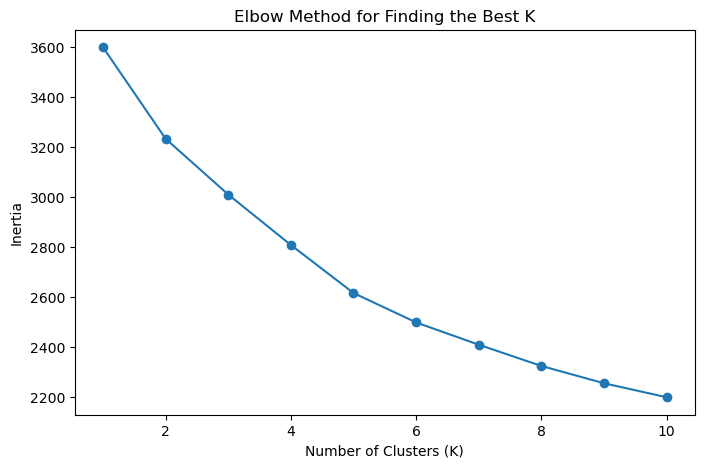

In [163]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()

In [164]:
elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,3600.000000
1,2,3233.946110
2,3,3010.728969
3,4,2809.060626
4,5,2616.900632
5,6,2499.169348
6,7,2410.072349
7,8,2325.025743
8,9,2255.820535
9,10,2199.952364


Based on the Elbow Method, I selected K = 3 because the inertia decreases as K increases, but the improvement becomes smaller after 3 clusters. This means 3 clusters gives a clear and simple segmentation without making too many small groups. For business interpretation, 3 segments are also easier for ProcurePro to understand and use.

In [165]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_labels[:10]

array([0, 2, 1, 0, 2, 2, 0, 0, 0, 0], dtype=int32)

In [166]:
pd.Series(cluster_labels).value_counts().sort_index()

0    125
1     96
2    139
Name: count, dtype: int64

In [167]:
df_clustered = df_clean.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,...,Supplier_Rating,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk,Cluster
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,...,3.8,No,Rare,1,1,2455,2,1.15,Yes,0
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,...,4.2,No,Unknown,0,3,1715,24,1.43,Yes,2
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,...,4.2,No,Rare,0,1,284,5,1.63,Yes,1
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,...,2.4,No,Unknown,0,2,971,32,1.83,Yes,0
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,...,4.9,No,Unknown,0,2,630,12,1.47,No,2


## Task 4: Analyze and Interpret the Clusters

In [168]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    125
1     96
2    139
Name: count, dtype: int64

In [169]:
cluster_summary = df_clustered.groupby("Cluster")[features].mean().round(2)

cluster_summary

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index
Cluster,,,,,,,,,,
0,5929.13,7.03,9.59,0.71,3.15,0.76,1.10,627.02,17.44,1.27
1,5345.34,6.46,13.23,0.83,3.99,1.70,1.67,552.17,8.96,1.47
2,6193.21,6.37,9.22,0.88,4.22,0.37,1.62,1112.54,17.65,1.26


In [170]:
cluster_summary_final = cluster_summary.copy()

cluster_summary_final["Number_of_Orders"] = cluster_counts

cluster_summary_final

,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,Past_On_Time_Rate,Supplier_Rating,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Number_of_Orders
Cluster,,,,,,,,,,,
0,5929.13,7.03,9.59,0.71,3.15,0.76,1.10,627.02,17.44,1.27,125
1,5345.34,6.46,13.23,0.83,3.99,1.70,1.67,552.17,8.96,1.47,96
2,6193.21,6.37,9.22,0.88,4.22,0.37,1.62,1112.54,17.65,1.26,139


In [171]:
summary = cluster_summary_final.copy()

low_reliability_cluster = summary["Past_On_Time_Rate"].idxmin()

remaining_clusters = summary.drop(index=low_reliability_cluster)
low_buffer_cluster = remaining_clusters["Inventory_Buffer_Days"].idxmin()

reliable_long_distance_cluster = summary.drop(
    index=[low_reliability_cluster, low_buffer_cluster]
).index[0]

segment_names = {
    low_reliability_cluster: "High Delay Risk / Lower Supplier Reliability",
    low_buffer_cluster: "Moderate Risk / Low Inventory Buffer",
    reliable_long_distance_cluster: "More Reliable but Long Distance Orders"
}

df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

df_clustered.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,...,Urgent_Order,Backorder_History,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk,Cluster,Segment_Name
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,...,No,Rare,1,1,2455,2,1.15,Yes,0,High Delay Risk / Lower Supplier Reliability
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,...,No,Unknown,0,3,1715,24,1.43,Yes,2,More Reliable but Long Distance Orders
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,...,No,Rare,0,1,284,5,1.63,Yes,1,Moderate Risk / Low Inventory Buffer
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,...,No,Unknown,0,2,971,32,1.83,Yes,0,High Delay Risk / Lower Supplier Reliability
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,...,No,Unknown,0,2,630,12,1.47,No,2,More Reliable but Long Distance Orders


In [172]:
df_clustered["Segment_Name"].value_counts()

Segment_Name
More Reliable but Long Distance Orders          139
High Delay Risk / Lower Supplier Reliability    125
Moderate Risk / Low Inventory Buffer             96
Name: count, dtype: int64

In [173]:
segment_interpretation = pd.DataFrame({
    "Cluster": [0, 1, 2],
    "Segment Name": [
        "High Delay Risk / Lower Supplier Reliability",
        "Moderate Risk / Low Inventory Buffer",
        "More Reliable but Long Distance Orders"
    ],
    "Main Characteristics": [
        "Lower past on-time rate, lower supplier rating, and weaker supplier reliability.",
        "Lowest inventory buffer, highest seasonal demand index, more quality incidents, and more prior delays.",
        "Highest past on-time rate, highest supplier rating, low quality incidents, but longest delivery distance."
    ],
    "Business Meaning": [
        "This group needs closer monitoring because supplier performance is weaker.",
        "This group needs more marketing and operations attention because low inventory buffer gives the business less time to react.",
        "This group appears more reliable, but long distance should still be monitored for delivery planning."
    ]
})

segment_interpretation

,Cluster,Segment Name,Main Characteristics,Business Meaning
0,0,High Delay Risk / Lower Supplier Reliability,"Lower past on-time rate, lower supplier rating...",This group needs closer monitoring because sup...
1,1,Moderate Risk / Low Inventory Buffer,"Lowest inventory buffer, highest seasonal dema...",This group needs more marketing and operations...
2,2,More Reliable but Long Distance Orders,"Highest past on-time rate, highest supplier ra...","This group appears more reliable, but long dis..."


### Cluster Interpretation

The K-means model found 3 purchase order segments.

Cluster 0: High Delay Risk / Lower Supplier Reliability  
This segment has weaker supplier performance because it has a lower past on-time rate and lower supplier rating. This group needs closer monitoring because these orders may create delivery problems for ProcurePro.

Cluster 1: Moderate Risk / Low Inventory Buffer  
This segment has a lower inventory buffer and higher seasonal demand pressure. This means the business has less time to react if the order is delayed. This group needs more marketing and operations attention because customers may need earlier updates.

Cluster 2: More Reliable but Long Distance Orders  
This segment has stronger supplier reliability, including a higher past on-time rate and better supplier rating. However, this group also has longer delivery distance, so ProcurePro should still monitor shipping timelines. This group may be valuable because these suppliers are more dependable and can support better customer satisfaction.

## Task 5: Visualize the Clusters

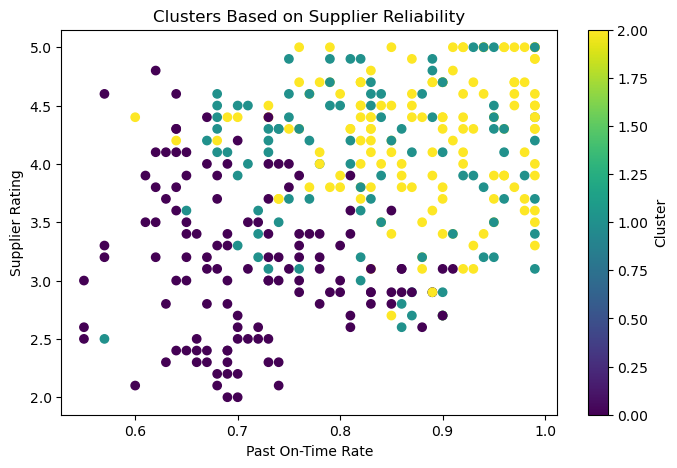

In [174]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clustered["Past_On_Time_Rate"],
    df_clustered["Supplier_Rating"],
    c=df_clustered["Cluster"]
)

plt.xlabel("Past On-Time Rate")
plt.ylabel("Supplier Rating")
plt.title("Clusters Based on Supplier Reliability")
plt.colorbar(label="Cluster")
plt.show()

The scatter plot compares past on-time rate and supplier rating across the clusters. It helps show how supplier reliability differs between the groups. Clusters with higher on-time rates and higher supplier ratings appear more reliable, while clusters with lower values may need closer monitoring.

In [175]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

df_clustered.head()

,Purchase_Order_ID,Supplier_Category,Supplier_Region,Contract_Type,Shipping_Mode,Payment_Terms,Seasonal_Period,Order_Value_CAD,Number_of_Line_Items,Promised_Lead_Time_Days,...,Quality_Incidents_Last_6M,Prior_Delays_Last_6M,Distance_KM,Inventory_Buffer_Days,Seasonal_Demand_Index,Supplier_Delay_Risk,Cluster,Segment_Name,PCA1,PCA2
0,PO-20260001,Breakroom Supplies,British Columbia,New Supplier,Local Courier,Prepaid,Regular,4214.00,12,6,...,1,1,2455,2,1.15,Yes,0,High Delay Risk / Lower Supplier Reliability,-0.573014,0.822935
1,PO-20260002,IT Accessories,Alberta,Approved Vendor,Expedited Ground,Net 30,Fiscal Year End,6895.44,12,13,...,0,3,1715,24,1.43,Yes,2,More Reliable but Long Distance Orders,-0.352254,1.841932
2,PO-20260003,Packaging Materials,Ontario,Preferred Vendor,Air Freight,Net 30,Holiday Rush,3890.34,7,3,...,0,1,284,5,1.63,Yes,1,Moderate Risk / Low Inventory Buffer,0.131205,-0.639057
3,PO-20260004,Printing Supplies,US Midwest,New Supplier,Standard Ground,Prepaid,Holiday Rush,10486.43,2,16,...,0,2,971,32,1.83,Yes,0,High Delay Risk / Lower Supplier Reliability,-1.838491,0.721885
4,PO-20260005,Breakroom Supplies,Quebec,Preferred Vendor,Standard Ground,Net 30,Regular,4255.70,2,7,...,0,2,630,12,1.47,No,2,More Reliable but Long Distance Orders,2.315250,-1.047219


In [176]:
pca_intro = pd.DataFrame({
    "Concept": ["PCA", "Principal Component", "Purpose", "Important Note"],
    "Meaning": [
        "Principal Component Analysis",
        "A new combined feature created from the original features",
        "Helps visualize high-dimensional data in fewer dimensions",
        "PCA does not create clusters; K-means creates the clusters."
    ]
})

pca_intro

,Concept,Meaning
0,PCA,Principal Component Analysis
1,Principal Component,A new combined feature created from the origin...
2,Purpose,Helps visualize high-dimensional data in fewer...
3,Important Note,PCA does not create clusters; K-means creates ...


In [177]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by PCA1:", explained_variance[0])
print("Explained variance by PCA2:", explained_variance[1])
print("Total explained variance:", explained_variance.sum())

Explained variance by PCA1: 0.1431701669840048
Explained variance by PCA2: 0.13198759823888673
Total explained variance: 0.27515776522289154


In [178]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = df_clustered["Cluster"].values

pca_df.head()

,PC1,PC2,Cluster
0,-0.573014,0.822935,0
1,-0.352254,1.841932,2
2,0.131205,-0.639057,1
3,-1.838491,0.721885,0
4,2.315250,-1.047219,2


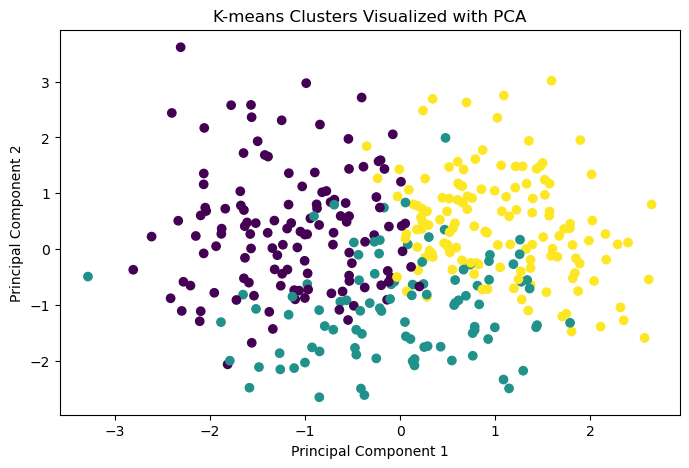

In [179]:
plt.figure(figsize=(8, 5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clusters Visualized with PCA")
plt.show()

The PCA scatter plot shows the K-means clusters in two dimensions. Since the model used many numerical features, PCA helps simplify the visualization. The chart shows how purchase orders are grouped based on similar supplier and order characteristics.

In [180]:
pca_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained Variance Ratio": pca.explained_variance_ratio_
})

pca_variance

,Component,Explained Variance Ratio
0,PC1,0.143170
1,PC2,0.131988


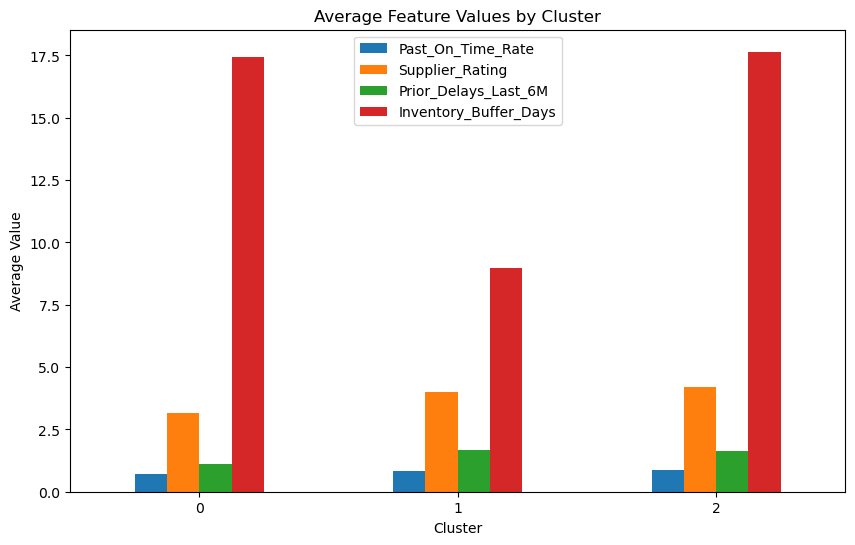

In [181]:
bar_features = [
    "Past_On_Time_Rate",
    "Supplier_Rating",
    "Prior_Delays_Last_6M",
    "Inventory_Buffer_Days"
]

# Create bar chart comparing cluster averages
cluster_summary[bar_features].plot(kind="bar", figsize=(10, 6))

plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Average Feature Values by Cluster")
plt.xticks(rotation=0)
plt.show()

The bar chart compares the average values of key features across the clusters. It shows differences in supplier reliability, prior delays, and inventory buffer. This helps ProcurePro understand which cluster is more reliable and which cluster may need more business attention.

## Task 6: Business Interpretation

1. What patterns did you discover?

   The clustering results showed three main purchase order segments. One group has lower supplier reliability, such as lower past on-time performance and weaker supplier ratings. Another group has a lower inventory buffer, meaning ProcurePro has less time to react if delays happen. The third group appears more reliable because suppliers have stronger on-time performance and better ratings, but these orders may involve longer delivery distances.

2. How can the business use these customer/user segments?

   ProcurePro can use these segments to decide which purchase orders need the most attention. Instead of treating all orders the same, the company can prioritize supplier follow-up, customer communication, backup planning, and inventory monitoring based on the segment each order belongs to.


3. What marketing strategy would you suggest for each segment?

   For the High Delay Risk / Lower Supplier Reliability segment, ProcurePro should use proactive communication by warning customers earlier about possible delays and preparing backup supplier options.
   For the Moderate Risk / Low Inventory Buffer segment, ProcurePro should encourage earlier reordering and send reminders to customers before inventory becomes too low.
   For the More Reliable but Long Distance Orders segment, ProcurePro should maintain strong supplier relationships and promote these suppliers as dependable options, while still monitoring shipping timelines because of the longer distance.

4. How can this analysis help the business improve decision-making?

   This analysis helps ProcurePro make better decisions by showing which groups are more reliable and which groups need closer monitoring. The business can use the clusters to reduce last minute delivery problems, improve customer satisfaction, plan inventory more carefully, and focus time and resources on the orders that have the highest business impact.



## Task 7: Limitations and Responsible AI Reflection

1. What is one limitation of your dataset or clustering model?

   One limitation is that the dataset may not include all real-world factors that can affect supplier delivery performance. For example, delays could also be caused by weather, strikes, sudden product shortages, transportation problems, or unexpected customer demand. Since these factors aren't fully included, the clusters may not explain every reason why some purchase orders are more difficult to manage.

2. Why does K-means not always produce perfect customer segments?

   K-means doesn't always create perfect segments because it groups records based on numerical distance. This means the model may place purchase orders in the same cluster even if they are different from a business perspective. The results can also change depending on which features are selected, how the data is scaled, and how many clusters are chosen.

3. What kind of bias or unfair decision could happen if the business uses these clusters without human review?

   If ProcurePro uses the clusters without human review, the business might unfairly assume that some suppliers or order groups are always risky. For example, a supplier in a lower reliability segment might have improved recently, but the business may still give them less trust or fewer opportunities based only on past data. Some supplier regions or categories could also be judged unfairly if the historical data overrepresents delays from those groups.

4. Why should human judgment still be used when making marketing decisions?

   Human judgment is still important because the model only shows patterns in the data. Managers should also consider current supplier communication, contract terms, customer priority, inventory needs, and recent market conditions before making decisions. K-means can support marketing and business planning, but it shouldn't replace human review.

In [182]:
output_file = "procurepro_clustered_dataset.csv"

df_clean.to_csv(output_file, index=False)

print("Clustered dataset saved as:", output_file)

Clustered dataset saved as: procurepro_clustered_dataset.csv
